In [1]:
#Step 1: INSTALLING NECESSARY PACKAGES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [2]:
#Step 1.1 : Loading the data 
df = pd.read_csv("Online Retail.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
#Step 1.2: checking the structure for the data 
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
#STEP2: checking data quality issues
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
(df.isna().mean() * 100).sort_values(ascending=False)

CustomerID     24.926694
Description     0.268311
InvoiceNo       0.000000
StockCode       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [6]:
#Step 2.2: checking duplicate records
df.duplicated(keep=False).sum()

10147

In [7]:
df[df.duplicated(keep=False)].sort_values(
    by=df.columns.tolist()
)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
440149,C574510,22360,GLASS JAR ENGLISH CONFECTIONERY,-1,11/4/2011 13:25,2.95,15110.0,United Kingdom
461407,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
461408,C575940,23309,SET OF 60 I LOVE LONDON CAKE CASES,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom
529980,C580764,22667,RECIPE BOX RETROSPOT,-12,12/6/2011 10:38,2.95,14562.0,United Kingdom


In [8]:
#Step 2.3: checking invalid/suspicious values 
df['Quantity'].describe()


count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [9]:
df['UnitPrice'].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [10]:
#STEP 3: DATA CLEANING 
#Step 3.1: REMOVING MISSING CUSTOMERIDs
df = df.dropna(subset=['CustomerID'])

#Step 3.2: REMOVING CANCELLED INVOICES 
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

#Syep 3.3: REMOVING INVALID QUANTITY AND PRICE 
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

In [11]:
#Step 3.4: CONFIRM CLEANING 
df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [12]:
df.shape

(397884, 8)

In [13]:
#STEP 4: Feature Engineering 
#Total Sales
df['TotalSales'] = df['Quantity'] * df['UnitPrice']

#Data Handlying 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')

In [14]:
#STEP 5: Descriptive Statistics 
#Step 5.1: Numerical Summary
df[['Quantity', 'UnitPrice', 'TotalSales']].describe() 

,Quantity,UnitPrice,TotalSales
count,397884.000000,397884.000000,397884.000000
mean,12.988238,3.116488,22.397000
std,179.331775,22.097877,309.071041
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.680000
50%,6.000000,1.950000,11.800000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [15]:
#Step 5.2: Business KPIs
print("Total Revenue:", df['TotalSales'].sum())
print("Unique Invoices:", df['InvoiceNo'].nunique())
print("Unique Customers:", df['CustomerID'].nunique())

Total Revenue: 8911407.904
Unique Invoices: 18532
Unique Customers: 4338


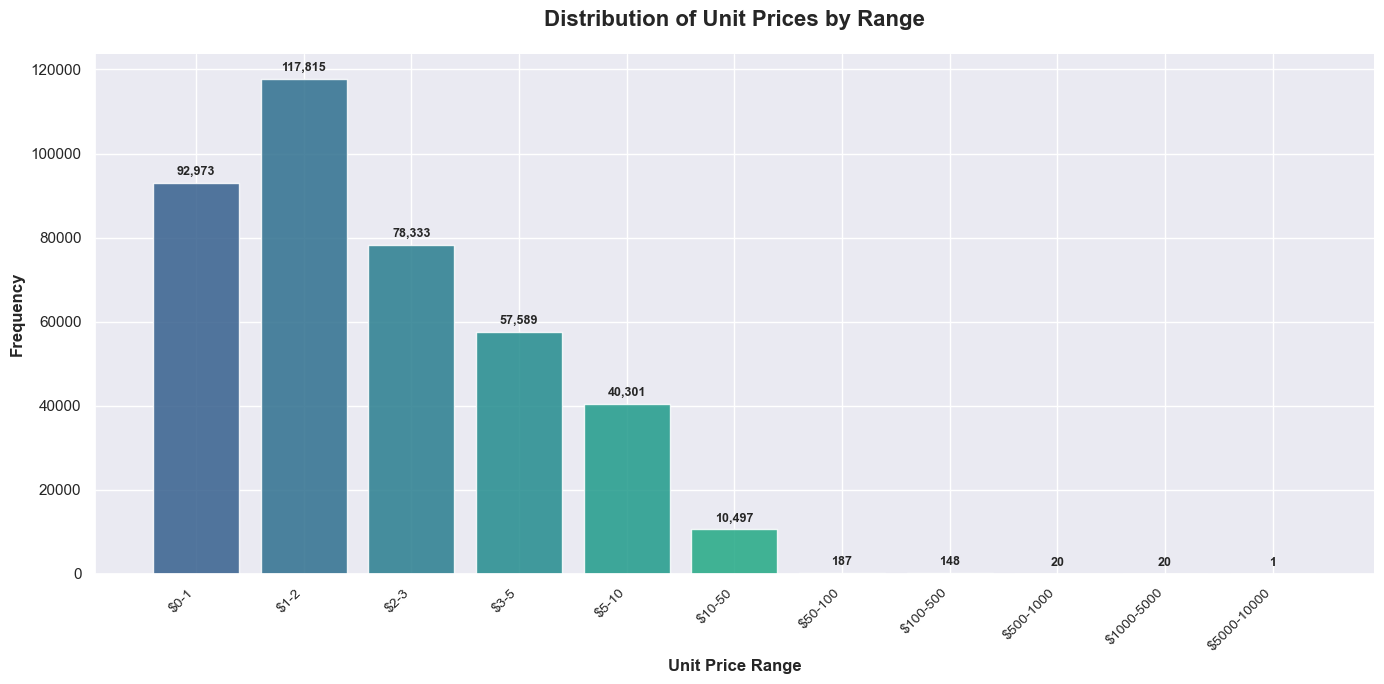

In [26]:
#STEP 6: VISIALISATION
# Setting seaborn style
sns.set_style('darkgrid')

# Defining price bins
bins = [0, 1, 2, 3, 5, 10, 50, 100, 500, 1000, 5000, 10000]
hist, edges = np.histogram(df['UnitPrice'], bins=bins)


fig, ax = plt.subplots(figsize=(14, 7))

# Gradient colors
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(hist)))

# Plot bars
bars = ax.bar(range(len(hist)), hist, color=colors, edgecolor='white', alpha=0.85)

# X-axis labels
labels = [f"${int(edges[i])}-{int(edges[i+1])}" for i in range(len(edges)-1)]
ax.set_xticks(range(len(hist)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)

# Adding frequency labels
for bar, value in zip(bars, hist):
    if value > 0:
        ax.text(bar.get_x() + bar.get_width()/2, value + max(hist)*0.01, f"{int(value):,}",
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Titles and labels
ax.set_title("Distribution of Unit Prices by Range", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Unit Price Range", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')

# Removing top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("unit_price_distribution.png", dpi=300) 
plt.show()


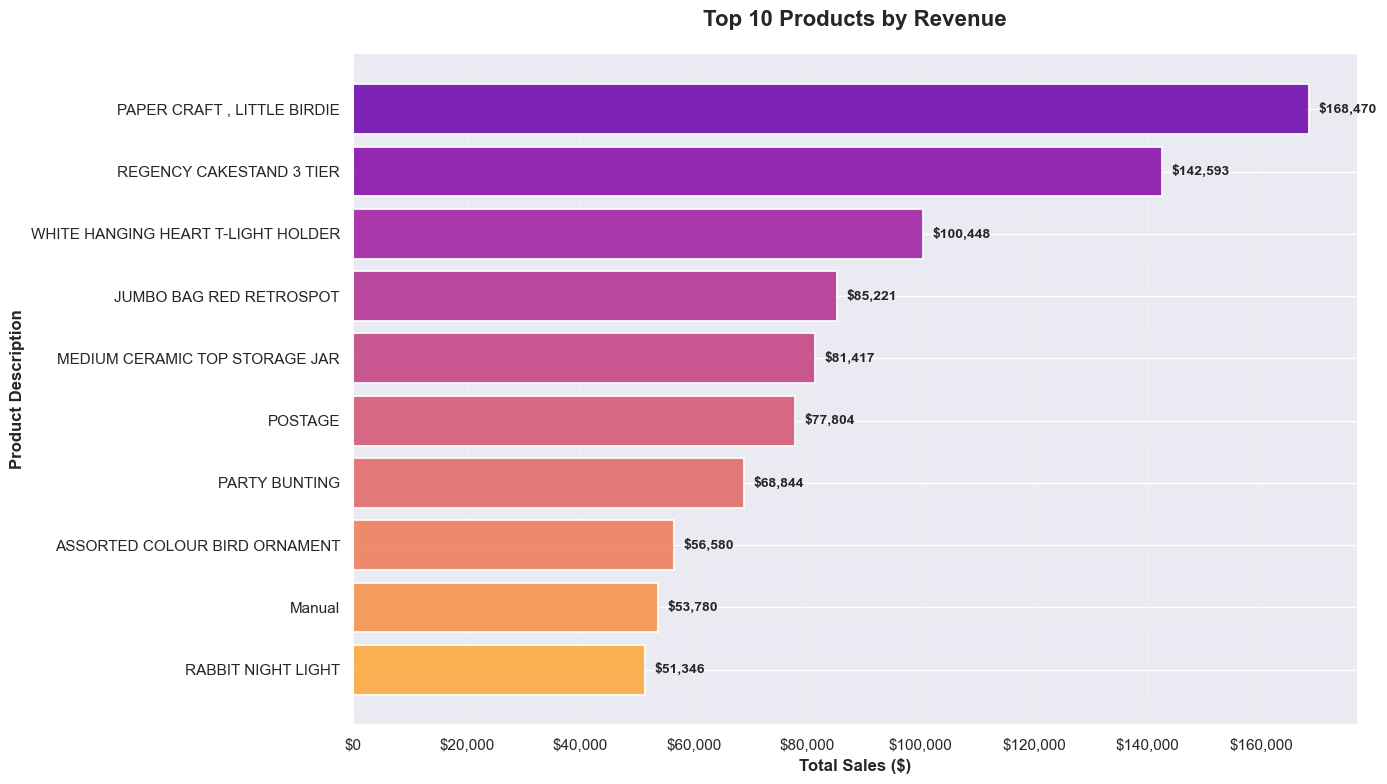

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set seaborn style
sns.set_style('darkgrid')

# Get top 10 products by revenue
top_products = (
    df.groupby('Description')['TotalSales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Gradient colors
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_products)))

# Horizontal bar chart
bars = ax.barh(range(len(top_products)), top_products.values, color=colors, 
               edgecolor='white', linewidth=1.5, alpha=0.85)

# Y-axis labels
ax.set_yticks(range(len(top_products)))
ax.set_yticklabels(top_products.index, fontsize=11)
ax.invert_yaxis()  # Highest revenue at top

# Add value labels at the end of bars
for i, (bar, value) in enumerate(zip(bars, top_products.values)):
    ax.text(value + max(top_products.values)*0.01, bar.get_y() + bar.get_height()/2, 
            f'${value:,.0f}', va='center', fontsize=10, fontweight='bold')

# Titles and labels
ax.set_title("Top 10 Products by Revenue", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Total Sales ($)", fontsize=12, fontweight='bold')
ax.set_ylabel("Product Description", fontsize=12, fontweight='bold')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Gridlines for x-axis
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Format x-axis as currency
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig("Top_10_Products_by_revenue.png", dpi=300) 
plt.show()


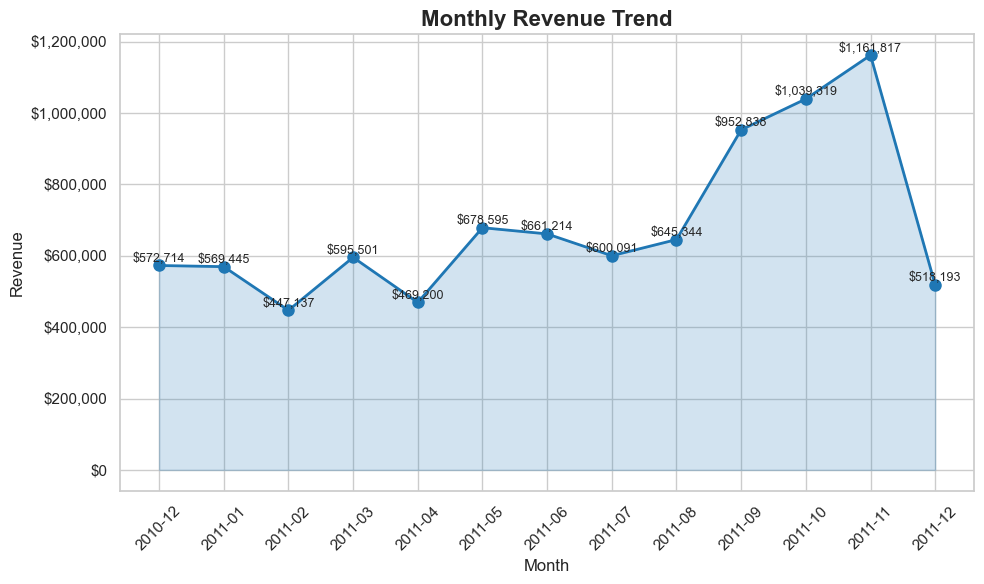

In [28]:
#Step 6.2: Monthly trend Visualization
import matplotlib.ticker as mtick

#Calculating monthly sales
monthly_sales = df.groupby('Month')['TotalSales'].sum()

# Converting index to string for plotting
monthly_sales_str = monthly_sales.copy()
monthly_sales_str.index = monthly_sales_str.index.astype(str)


sns.set(style="whitegrid")
plt.figure(figsize=(10,6))


plt.plot(monthly_sales_str.index, monthly_sales_str.values, marker='o', color="#1f77b4", linewidth=2, markersize=8)
plt.fill_between(monthly_sales_str.index, monthly_sales_str.values, color="#1f77b4", alpha=0.2)

# Adding value labels
for i, value in enumerate(monthly_sales_str.values):
    plt.text(i, value + 1000, f"${value:,.0f}", ha='center', va='bottom', fontsize=9)


plt.title("Monthly Revenue Trend", fontsize=16, weight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)

# Formatting y-axis as currency
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

#  Rotating x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("monthly_revenue_trend.png", dpi=300) 
plt.show()


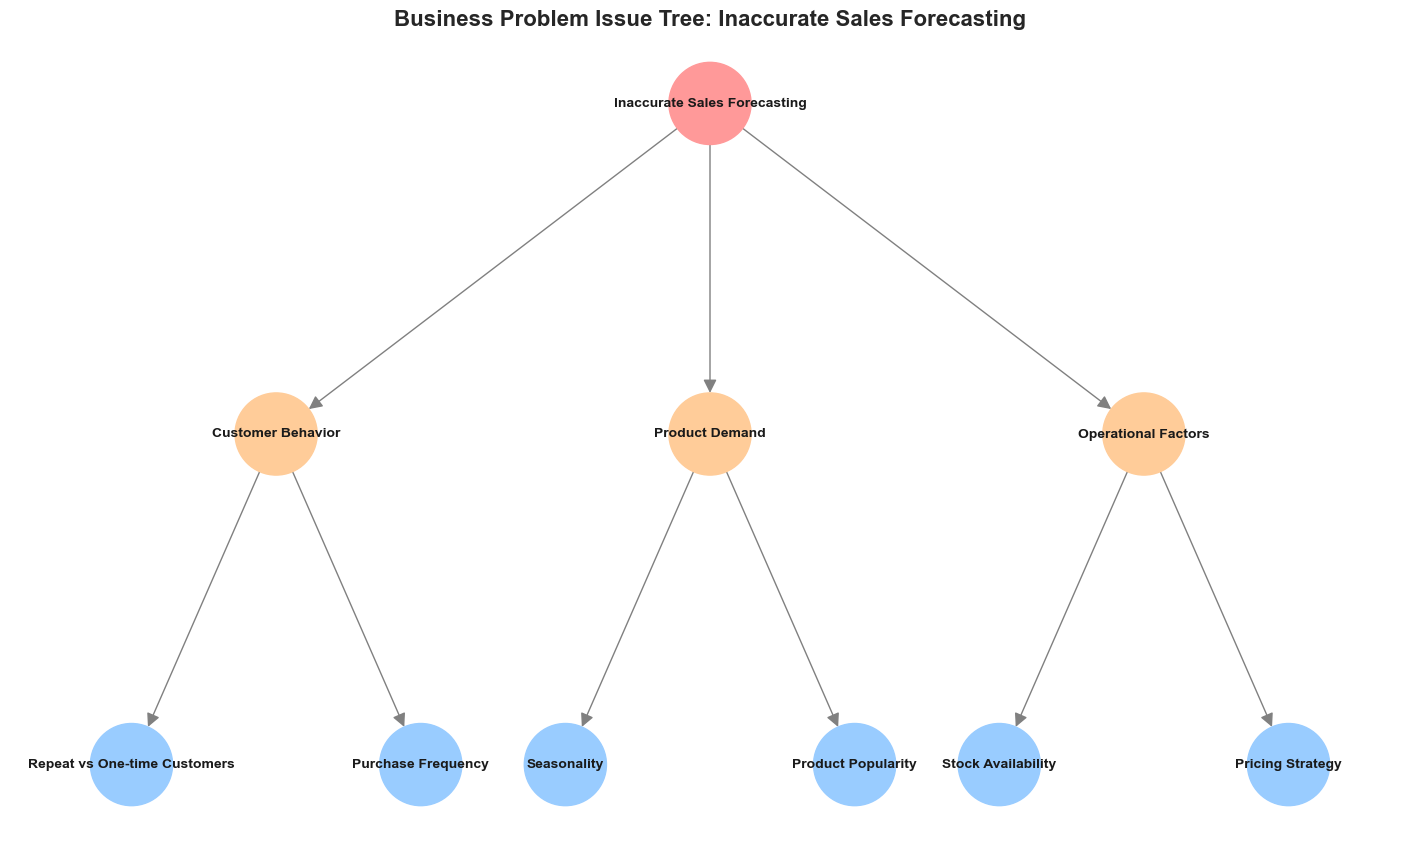

In [31]:
#STEP 7: ISSUE TREES
import networkx as nx


G = nx.DiGraph()

# Adding edges (issue tree structure)
edges = [
    ("Inaccurate Sales Forecasting", "Customer Behavior"),
    ("Inaccurate Sales Forecasting", "Product Demand"),
    ("Inaccurate Sales Forecasting", "Operational Factors"),

    ("Customer Behavior", "Repeat vs One-time Customers"),
    ("Customer Behavior", "Purchase Frequency"),

    ("Product Demand", "Seasonality"),
    ("Product Demand", "Product Popularity"),

    ("Operational Factors", "Stock Availability"),
    ("Operational Factors", "Pricing Strategy"),
]

G.add_edges_from(edges)

# Defining positions 
pos = {
    "Inaccurate Sales Forecasting": (0, 3),

    "Customer Behavior": (-3, 2),
    "Product Demand": (0, 2),
    "Operational Factors": (3, 2),

    "Repeat vs One-time Customers": (-4, 1),
    "Purchase Frequency": (-2, 1),

    "Seasonality": (-1, 1),
    "Product Popularity": (1, 1),

    "Stock Availability": (2, 1),
    "Pricing Strategy": (4, 1),
}

# Defining node colors
node_colors = []
for node in G.nodes():
    if node == "Inaccurate Sales Forecasting":
        node_colors.append("#ff9999")  # root node: red-ish
    elif node in ["Customer Behavior", "Product Demand", "Operational Factors"]:
        node_colors.append("#ffcc99")  # intermediate nodes: orange
    else:
        node_colors.append("#99ccff")  # leaf nodes: blue

plt.figure(figsize=(14, 8))
nx.draw(
    G, pos,
    with_labels=True,
    node_size=3500,
    node_color=node_colors,
    node_shape="o",         
    font_size=10,
    font_weight="bold",
    arrowsize=20,           
    edge_color="gray"
)

plt.title("Business Problem Issue Tree: Inaccurate Sales Forecasting", fontsize=16, weight='bold')
plt.axis("off")
plt.savefig("Business.png", dpi=300) 
plt.show()


In [20]:
#STEP 8: Predictive Task
#Step 8.1: Customer Aggregation
customer_df = (
    df.groupby('CustomerID')
    .agg(
        TotalSpend=('TotalSales', 'sum'),
        AvgQuantity=('Quantity', 'mean'),
        NumPurchases=('InvoiceNo', 'nunique')
    )
    .reset_index()
)


In [21]:
#Step 8.2: Target Variable 
customer_df['RepeatCustomer'] = np.where(
    customer_df['NumPurchases'] > 1, 1, 0
)


In [22]:
#STEP 9: Model Building
#Train/Test split 
X = customer_df[['TotalSpend', 'AvgQuantity', 'NumPurchases']]
y = customer_df['RepeatCustomer']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [23]:
#Step 9.1: Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [24]:
#Step 9.2: Train model
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [25]:
#Step 9.3: Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9984639016897081
[[418   1]
 [  1 882]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       419
           1       1.00      1.00      1.00       883

    accuracy                           1.00      1302
   macro avg       1.00      1.00      1.00      1302
weighted avg       1.00      1.00      1.00      1302

